# Lab Assignment 8
## Neural Machine Translation for English-to-German using LSTMs
---

### Objective

The goal of this assignment is to build, train, and test a Neural Machine Translation (NMT) model
capable of translating English sentences into German. You will achieve this by adapting a
sequence-to-sequence (Seq2Seq) model based on Long Short-Term Memory (LSTM) networks.

### Provided Materials

A complete working notebook that implements an **English-to-French** translator has been shared with you. Your task is to modify the logic in that
reference code to work for the English-to-German language pair.

**You are expected to write the code yourself.** This notebook tells you *what* each task must
produce — the function names, the variables, and the exact output your code must print — but not
*how* to write it. Adapt the reference notebook.

### Marks

| Task | Description | Marks |
|---|---|---|
| **Task 1** | Data Adaptation | **4** |
| **Task 2** | Model Training | **5** |
| **Task 3** | Inference and Translation | **6** |
| **Task 4** | Beam Search Decoding | **5** |
| | **Total** | **20** |

---

### Before you start

- **Use a GPU.** In Colab: `Runtime → Change runtime type → T4 GPU`. Training 40 epochs takes
  roughly **15–25 minutes on a GPU** and well over an hour on CPU. **Start Task 2 training early**
  and write your Task 4 code while it runs.
- **The reference notebook is incomplete.** It calls a function `decode_sequence(...)` that it
  never defines. Writing that function is part of Task 3.
- Saving to `.h5` prints a "legacy format" warning on current Keras. It is harmless.
- Do **not** change the model architecture. Tasks 1–3 adapt the data and the inference code;
  Task 4 improves the *decoding*, not the model.

---
## Setup

These are the only values given to you. Everything else you write yourself.

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

batch_size  = 64
epochs      = 40          # Task 2 requires at least 40
latent_dim  = 256
num_samples = 10000

print("TensorFlow", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.20.0
GPU available: True


---
# Task 1: Data Adaptation &nbsp;&nbsp;*(4 marks)*

Your first task is to replace the data pipeline to use the English-to-German dataset.

1. In the data acquisition section of your code, download the English-German data uploaded in classroom.
2. After downloading and unzipping, ensure you update the `data_path` variable to point to the
   correct text file: `deu.txt`.
3. Run the data loading and preprocessing steps. **For your submission, report the following
   statistics** that are printed to the console:
   * `Number of samples:`
   * `Number of unique input tokens:`
   * `Number of unique output tokens:`
   * `Max sequence length for inputs:`

### What your code must create

| Variable | Holds |
|---|---|
| `input_texts`, `target_texts` | the English and German sentences |
| `input_characters`, `target_characters` | the sorted character vocabularies |
| `num_encoder_tokens`, `num_decoder_tokens` | sizes of those vocabularies |
| `max_encoder_seq_length`, `max_decoder_seq_length` | longest input and output |
| `input_token_index`, `target_token_index` | character → index dictionaries |
| `encoder_input_data`, `decoder_input_data`, `decoder_target_data` | the three one-hot tensors |

### Output your code must print

```
Number of samples: ...
Number of unique input tokens: ...
Number of unique output tokens: ...
Max sequence length for inputs: ...
Max sequence length for outputs: ...
```

### Hints

- The German file has the **same three-column tab-separated format** as the French one, so the
  parsing logic does not change: splitting a line on tabs gives `[english, german, attribution]`.
- Wrap every German sentence with a **start marker** (`'\t'`) and an **end marker** (`'\n'`).
  Without them the decoder never learns where a translation begins or ends.
- **Teacher forcing.** `decoder_target_data` is `decoder_input_data` shifted **left by one step**:
  at position `t` the decoder must *predict* the character it was *given* at position `t`. There
  is nothing to predict before the start marker.
- Pad the unused positions of all three tensors with the space character.
- German adds characters English does not have (`ä ö ü ß`, and `Ä Ö Ü`), so expect
  `num_decoder_tokens` to be noticeably larger than `num_encoder_tokens`.

In [16]:
# ---------------- TASK 1 ----------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

batch_size = 64
epochs = 40
latent_dim = 256
num_samples = 10000


# TODO 1: Set data path

data_path = "deu.txt"


# TODO 2: Read the English-German file

input_texts = []
target_texts = []

with open(data_path, encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")

        if len(parts) < 2:
            continue

        input_text = parts[0]
        target_text = parts[1]

        input_texts.append(input_text)

        # Start marker = \t
        # End marker = \n
        target_texts.append("\t" + target_text + "\n")

        if len(input_texts) >= num_samples:
            break


# Build character vocabularies

input_characters = sorted(
    set(char for text in input_texts for char in text)
)

target_characters = sorted(
    set(char for text in target_texts for char in text)
)


# TODO 3: Compute statistics

num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)

max_encoder_seq_length = max(
    len(text) for text in input_texts
)

max_decoder_seq_length = max(
    len(text) for text in target_texts
)


# TODO 4: Build character -> index dictionaries

input_token_index = {
    char: i
    for i, char in enumerate(input_characters)
}

target_token_index = {
    char: i
    for i, char in enumerate(target_characters)
}


# TODO 5: Print required statistics

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)


# TODO 6: Build one-hot tensors

encoder_input_data = np.zeros(
    (
        len(input_texts),
        max_encoder_seq_length,
        num_encoder_tokens
    ),
    dtype="float32"
)

decoder_input_data = np.zeros(
    (
        len(input_texts),
        max_decoder_seq_length,
        num_decoder_tokens
    ),
    dtype="float32"
)

decoder_target_data = np.zeros(
    (
        len(input_texts),
        max_decoder_seq_length,
        num_decoder_tokens
    ),
    dtype="float32"
)


# Padding character = space

space_index_encoder = input_token_index[" "]
space_index_decoder = target_token_index[" "]


# Fill tensors

for i, (input_text, target_text) in enumerate(
    zip(input_texts, target_texts)
):

    # ---------------- ENCODER INPUT ----------------

    for t, char in enumerate(input_text):
        encoder_input_data[
            i,
            t,
            input_token_index[char]
        ] = 1.0

    # Pad remaining encoder positions with spaces

    for t in range(
        len(input_text),
        max_encoder_seq_length
    ):
        encoder_input_data[
            i,
            t,
            space_index_encoder
        ] = 1.0


    # ---------------- DECODER INPUT ----------------

    for t, char in enumerate(target_text):
        decoder_input_data[
            i,
            t,
            target_token_index[char]
        ] = 1.0

    # Pad remaining decoder positions with spaces

    for t in range(
        len(target_text),
        max_decoder_seq_length
    ):
        decoder_input_data[
            i,
            t,
            space_index_decoder
        ] = 1.0


    # ---------------- DECODER TARGET ----------------

    for t in range(1, len(target_text)):
        char = target_text[t]

        decoder_target_data[
            i,
            t - 1,
            target_token_index[char]
        ] = 1.0


    # Pad remaining target positions with spaces

    for t in range(
        len(target_text) - 1,
        max_decoder_seq_length
    ):
        decoder_target_data[
            i,
            t,
            space_index_decoder
        ] = 1.0

Number of samples: 10000
Number of unique input tokens: 70
Number of unique output tokens: 84
Max sequence length for inputs: 15
Max sequence length for outputs: 51


---
# Task 2: Model Training &nbsp;&nbsp;*(5 marks)*

Next, you will train the LSTM-based Encoder-Decoder model on the new English-German dataset.

1. Modify the code to save your newly trained model with a distinct name (e.g.,
   `s2s_eng_ger.h5`) to differentiate it from the original French model.
2. Train the model on the English-German data for at least **40 epochs**. It is highly
   recommended to use a GPU accelerator in Google Colab for this step.
3. For your submission, provide a **screenshot** of the console output from the final epoch of
   training. The screenshot must clearly show the final values for `loss`, `accuracy`,
   `val_loss`, and `val_accuracy`.

### What your code must create

| Name | Is |
|---|---|
| `encoder_inputs`, `encoder_states` | the encoder input, and its two final states |
| `decoder_inputs` | the decoder input |
| `decoder_lstm`, `decoder_dense` | the decoder **layer objects** — Task 3 reuses these |
| `model` | the full training model, compiled |
| `history` | the return value of `model.fit(...)` |

### Output your code must print

- `model.summary()`
- the final epoch line showing `loss`, `accuracy`, `val_loss`, `val_accuracy`
- confirmation that the model was saved

### Hints

- The encoder keeps only its **final states** — this is the "thought vector". Its outputs are
  discarded.
- The decoder is connected to the encoder by exactly **one argument**. Find it in the reference
  code; without it you have two unrelated LSTMs.
- The decoder LSTM must return a prediction at *every* time step, not just the last one.
- Keep `decoder_lstm` and `decoder_dense` as named variables. In Task 3 you must reuse **these
  same trained layer objects** — building new ones gives you untrained weights.
- Train with `validation_split=0.2` so you have the `val_loss` and `val_accuracy` the task asks for.

In [17]:
# ---------------- TASK 2 ----------------

# TODO 7: Build the encoder

encoder_inputs = Input(
    shape=(None, num_encoder_tokens),
    name="encoder_inputs"
)

encoder = LSTM(
    latent_dim,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder(encoder_inputs)

encoder_states = [state_h, state_c]


# TODO 8: Build the decoder

decoder_inputs = Input(
    shape=(None, num_decoder_tokens),
    name="decoder_inputs"
)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)


decoder_dense = Dense(
    num_decoder_tokens,
    activation="softmax",
    name="decoder_dense"
)

decoder_outputs = decoder_dense(decoder_outputs)


# TODO 9: Build and compile model

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# TODO 10: Train for at least 40 epochs

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2
)


# TODO 11: Save German-specific model

model.save("s2s_eng_ger.h5")

print("Model saved as s2s_eng_ger.h5")


# TODO 12: Print final epoch values

final_epoch = len(history.history["loss"])

print("\nFinal Epoch:", final_epoch)
print("loss:", history.history["loss"][-1])
print("accuracy:", history.history["accuracy"][-1])
print("val_loss:", history.history["val_loss"][-1])
print("val_accuracy:", history.history["val_accuracy"][-1])

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None, 70)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None, 84)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    334,848 │ encoder_inputs[0… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    349,184 │ decoder_inputs[0… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 84)  │     21,588 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 705,620 (2.69 MB)

 Trainable params: 705,620 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6815 - loss: 1.4085 - val_accuracy: 0.6545 - val_loss: 1.2557
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7074 - loss: 1.0799 - val_accuracy: 0.6860 - val_loss: 1.1094
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7455 - loss: 0.9408 - val_accuracy: 0.7305 - val_loss: 0.9823
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7784 - loss: 0.8136 - val_accuracy: 0.7640 - val_loss: 0.8508
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7953 - loss: 0.7306 - val_accuracy: 0.7594 - val_loss: 0.8275
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8063 - loss: 0.6827 - val_accuracy: 0.7663 - val_loss: 0.8360
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8129 - loss: 0.6600 - val_accuracy: 0.7937 - val_loss: 0.7132
Epoch 8/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8208 - loss: 0.6233 - val_accu

Model saved as s2s_eng_ger.h5

Final Epoch: 40
loss: 0.3409801125526428
accuracy: 0.9009532928466797
val_loss: 0.4860578775405884
val_accuracy: 0.8620685935020447


### Final Epoch Output

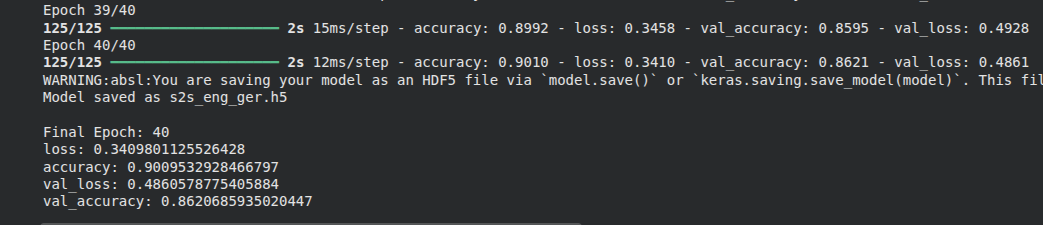

---
# Task 3: Inference and Translation &nbsp;&nbsp;*(6 marks)*

After the model is trained, you will test its ability to translate new English sentences into
German.

1. Ensure the inference part of your code is **correctly set up** to use the new German model and
   its corresponding vocabulary.
2. Using your translation function, translate the following five English sentences:
   * `I am very tired.`
   * `You are right.`
   * `He is a doctor.`
   * `Can you help me?`
   * `Let's go home.`
3. Present the translation results clearly in your submission, showing the original English input
   and the model's German translation for each of the five sentences.

### Why inference needs two new models

During training the decoder was always handed the *correct* previous character (teacher forcing).
At inference there is no correct answer, so the decoder must consume **its own predictions**, one
character at a time. The training model cannot do this, so you re-wire the **already-trained
layers** into two new models. No new training happens.

### What your code must create

| Name | Does |
|---|---|
| `encoder_model` | English sentence → the two encoder states. Run **once** per sentence |
| `decoder_model` | (one character + state) → (next-char probabilities + new state). Run **in a loop** |
| `reverse_target_char_index` | index → character, for reading predictions back |
| `encode_input(input_text)` | English string → one-hot array for the encoder |
| `decode_sequence(input_seq)` | one-hot array → German string, by **greedy** decoding |

### Output your code must print

```
ENGLISH             GERMAN (greedy)
---------------------------------------------
I am very tired.    ...
You are right.      ...
He is a doctor.     ...
Can you help me?    ...
Let's go home.      ...
```

### Hints

- `decode_sequence` is the function the reference notebook **calls but never defines**. You are
  writing it. Its loop: encode once, start from the `'\t'` marker, then repeatedly ask
  `decoder_model` for the next character, take the most likely one, stop at `'\n'`.
- **Carry the returned `[h, c]` forward** on every pass of the loop. If you do not, the decoder
  restarts from scratch at each character.
- Feed the character you just produced back in as the next decoder input.
- Reuse `decoder_lstm` and `decoder_dense` from Task 2. Building new layers runs without error and
  produces confident nonsense — a silent failure.

> ### Watch out — step 1 hides a real bug
> With `num_samples = 10000`, `max_encoder_seq_length` comes out as **15**. But
> `"I am very tired."` and `"Can you help me?"` are **16 characters long**. The reference code
> sizes its input array to exactly `max_encoder_seq_length` and then writes past the end of it,
> raising `IndexError`.
>
> Nothing is wrong with the model: the encoder is declared with `shape=(None, ...)`, and that
> `None` means an LSTM will read a sequence of **any** length. Only the array is too small.
> Fixing this is part of "ensure the inference part of your code is correctly set up".

In [20]:
# ---------------- TASK 3 ----------------

# TODO 13: Build encoder_model

encoder_model = Model(
    encoder_inputs,
    encoder_states
)


# TODO 14: Build decoder_model

decoder_state_input_h = Input(
    shape=(latent_dim,),
    name="decoder_state_input_h"
)

decoder_state_input_c = Input(
    shape=(latent_dim,),
    name="decoder_state_input_c"
)

decoder_states_inputs = [
    decoder_state_input_h,
    decoder_state_input_c
]


# Reuse the SAME trained decoder_lstm

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs,
    initial_state=decoder_states_inputs
)

decoder_states = [state_h, state_c]


# Reuse the SAME trained decoder_dense

decoder_outputs = decoder_dense(decoder_outputs)


decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states
)


# TODO 15: Build reverse target character index

reverse_target_char_index = {
    index: char
    for char, index in target_token_index.items()
}


# TODO 16 + 17: Encode English input

def encode_input(input_text):

    # The two test sentences can be 16 characters long,
    # while max_encoder_seq_length is 15.

    input_length = max(
        len(input_text),
        max_encoder_seq_length
    )

    input_data = np.zeros(
        (
            1,
            input_length,
            num_encoder_tokens
        ),
        dtype="float32"
    )

    for t, char in enumerate(input_text):

        if char in input_token_index:

            input_data[
                0,
                t,
                input_token_index[char]
            ] = 1.0

    # Pad remaining positions with spaces

    for t in range(
        len(input_text),
        input_length
    ):

        input_data[
            0,
            t,
            space_index_encoder
        ] = 1.0

    return input_data


# TODO 18 - 21: Greedy decoding

def decode_sequence(input_seq):

    # Run encoder once

    states_value = encoder_model.predict(
        input_seq,
        verbose=0
    )


    # Start decoder with '\t'

    target_seq = np.zeros(
        (1, 1, num_decoder_tokens),
        dtype="float32"
    )

    target_seq[
        0,
        0,
        target_token_index["\t"]
    ] = 1.0

    decoded_sentence = ""


    # Generate one character at a time

    for _ in range(max_decoder_seq_length):

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        # Greedy choice

        sampled_token_index = np.argmax(
            output_tokens[0, -1, :]
        )

        sampled_char = reverse_target_char_index[
            sampled_token_index
        ]

        # Stop at '\n'

        if sampled_char == "\n":
            break

        decoded_sentence += sampled_char


        # Feed predicted character back

        target_seq = np.zeros(
            (1, 1, num_decoder_tokens),
            dtype="float32"
        )

        target_seq[
            0,
            0,
            sampled_token_index
        ] = 1.0


        # Carry states forward

        states_value = [h, c]


    return decoded_sentence


# TODO 22: Test five required sentences

test_sentences = [
    "I am very tired.",
    "You are right.",
    "He is a doctor.",
    "Can you help me?",
    "Let's go home."
]

print()
print("ENGLISH".ljust(22) + "GERMAN (greedy)")
print("-" * 60)

for sentence in test_sentences:

    input_seq = encode_input(sentence)

    translation = decode_sequence(input_seq)

    print(
        sentence.ljust(22) + translation
    )


ENGLISH               GERMAN (greedy)
------------------------------------------------------------
I am very tired.      Ich bin nicht hier.
You are right.        Du bist nicht gewinnen.
He is a doctor.       Er hat mich geschlagen.
Can you help me?      Kann ich auf zu schnenden?
Let's go home.        Lass uns leinen sie.


---
# Task 4: Beam Search Decoding &nbsp;&nbsp;*(5 marks)*

### The problem with greedy decoding

`decode_sequence` is **greedy**: at every step it takes the single most likely next character and
never reconsiders. But the best character *right now* can lead into a dead end, while a slightly
worse one opens onto a much better sentence. Once greedy commits, it cannot back out — which is
why it produces German-shaped non-words.

### Beam search

Beam search keeps the **`k` best partial translations alive** at every step instead of one. At
each step it expands every live beam by its top `k` characters, scores all the candidates, and
keeps only the best `k` overall. A beam that produces `'\n'` is **complete** and is set aside.

A sequence is scored by the **sum of the log probabilities** of its characters:

$$\text{score}(y_1 \dots y_T) = \sum_{t=1}^{T} \log P(y_t \mid y_{<t}, x)$$

Two details you must get right:

1. **Add logs — never multiply probabilities.** Multiplying dozens of numbers below 1 underflows
   to zero. This is the same underflow problem you met with n-gram models.
2. **Normalise by length.** Every extra character adds another negative number, so a raw sum
   always favours the *shortest* translation. Divide by a power of the length:

$$\text{final score} = \frac{\sum_t \log P(y_t)}{|y|^{\alpha}} \qquad \alpha \approx 0.7$$

### What your code must create

| Name | Signature |
|---|---|
| `beam_search_decode` | `(input_seq, k=3, alpha=0.7)` → `(best_translation, best_score)` |

### Output your code must print

**(a)** the `k=1` sanity check — with a beam width of one, beam search must reproduce greedy
**exactly**:

```
greedy    : ...
beam k=1  : ...     <- must match greedy
```

**(b)** the comparison over all five sentences:

```
ENGLISH             GREEDY                    BEAM (k=3)                changed?
--------------------------------------------------------------------------------
...
Beam search changed the output for N of 5 sentences.
```

### Hints

- `decoder_model` already returns the **full probability distribution** over every character.
  Greedy throws all but the top one away — you keep the top `k`.
- `np.argsort(probs)[-k:]` gives the indices of the `k` largest probabilities.
- Represent each beam as a tuple of `(score, text_so_far, its own next input, its own [h, c])`.
- **Every beam must carry its own state.** Sharing one state across beams is the most common bug —
  it makes all beams collapse to the same output.
- Use `np.log(p + 1e-12)` so you never take `log(0)`.
- Stop once you have `k` completed beams, or after `max_decoder_seq_length` steps.
- Do the `k=1` check first. If that does not match greedy, nothing else will be right.
- **You do not need to retrain anything.** Beam search only changes how you read answers out of
  the model you already trained.

In [21]:
# ---------------- TASK 4 ----------------

def beam_search_decode(input_seq, k=3, alpha=0.7):

    # TODO 23:
    # Run encoder once

    initial_states = encoder_model.predict(
        input_seq,
        verbose=0
    )


    # TODO 24:
    # Initial beam

    start_token = np.zeros(
        (1, 1, num_decoder_tokens),
        dtype="float32"
    )

    start_token[
        0,
        0,
        target_token_index["\t"]
    ] = 1.0

    live_beams = [
        (
            0.0,
            "",
            start_token,
            initial_states
        )
    ]

    completed_beams = []


    # TODO 25:
    # Generate characters

    for step in range(max_decoder_seq_length):

        candidates = []

        for beam_score, beam_text, decoder_input, states in live_beams:

            output_tokens, h, c = decoder_model.predict(
                [decoder_input] + states,
                verbose=0
            )

            probs = output_tokens[0, -1, :]

            # Top k characters

            top_indices = np.argsort(probs)[-k:]


            for token_index in top_indices:

                probability = probs[token_index]

                # Add log probability

                new_score = (
                    beam_score +
                    np.log(probability + 1e-12)
                )

                sampled_char = reverse_target_char_index[
                    token_index
                ]


                # End marker

                if sampled_char == "\n":

                    completed_beams.append(
                        (
                            new_score,
                            beam_text
                        )
                    )

                else:

                    next_input = np.zeros(
                        (1, 1, num_decoder_tokens),
                        dtype="float32"
                    )

                    next_input[
                        0,
                        0,
                        token_index
                    ] = 1.0


                    # Each beam gets its own state

                    next_states = [
                        np.copy(h),
                        np.copy(c)
                    ]

                    candidates.append(
                        (
                            new_score,
                            beam_text + sampled_char,
                            next_input,
                            next_states
                        )
                    )


        if not candidates:
            break


        # Keep best k live beams

        candidates.sort(
            key=lambda x: x[0],
            reverse=True
        )

        live_beams = candidates[:k]


        # Stop after k completed beams

        if len(completed_beams) >= k:
            break


    # If no beam reached end marker

    if not completed_beams:

        for beam_score, beam_text, _, _ in live_beams:

            completed_beams.append(
                (
                    beam_score,
                    beam_text
                )
            )


    # TODO 26:
    # Length normalization

    scored_beams = []

    for total_log_score, text in completed_beams:

        length = max(len(text), 1)

        final_score = (
            total_log_score /
            (length ** alpha)
        )

        scored_beams.append(
            (
                final_score,
                text
            )
        )


    # TODO 27:
    # Select best beam

    scored_beams.sort(
        key=lambda x: x[0],
        reverse=True
    )

    best_score, best_translation = scored_beams[0]

    return best_translation, best_score


# --------------------------------------------------
# TODO 28: k=1 sanity check
# --------------------------------------------------

print("\n" + "=" * 70)
print("TASK 4 - BEAM SEARCH")
print("=" * 70)

sanity_sentence = test_sentences[0]

sanity_input = encode_input(
    sanity_sentence
)

greedy_translation = decode_sequence(
    sanity_input
)

beam_translation, beam_score = beam_search_decode(
    sanity_input,
    k=1,
    alpha=0.7
)

print("\nK=1 SANITY CHECK")
print("-" * 40)

print("greedy    :", greedy_translation)
print("beam k=1  :", beam_translation)

if greedy_translation == beam_translation:

    print(
        "PASS: Beam search with k=1 matches greedy."
    )

else:

    print(
        "WARNING: Beam search with k=1 does not match greedy."
    )


# --------------------------------------------------
# TODO 29: Compare greedy vs beam search
# --------------------------------------------------

print("\n")

print(
    "ENGLISH".ljust(22),
    "GREEDY".ljust(28),
    "BEAM (k=3)".ljust(28),
    "changed?"
)

print("-" * 90)

changed_count = 0

for sentence in test_sentences:

    input_seq = encode_input(sentence)

    greedy_result = decode_sequence(
        input_seq
    )

    beam_result, beam_score = beam_search_decode(
        input_seq,
        k=3,
        alpha=0.7
    )

    changed = greedy_result != beam_result

    if changed:
        changed_count += 1

    print(
        sentence.ljust(22),
        greedy_result.ljust(28),
        beam_result.ljust(28),
        str(changed)
    )


print("-" * 90)

print(
    f"Beam search changed the output for "
    f"{changed_count} of {len(test_sentences)} sentences."
)


TASK 4 - BEAM SEARCH

K=1 SANITY CHECK
----------------------------------------
greedy    : Ich bin nicht hier.
beam k=1  : Ich bin nicht hier.
PASS: Beam search with k=1 matches greedy.


ENGLISH                GREEDY                       BEAM (k=3)                   changed?
------------------------------------------------------------------------------------------
I am very tired.       Ich bin nicht hier.          Ich bin nicht hier.          False
You are right.         Du bist nicht gewinnen.      Sie können mich.             True
He is a doctor.        Er hat mich geschlagen.      Er hat mich sicher.          True
Can you help me?       Kann ich auf zu schnenden?   Können Sie sichen?           True
Let's go home.         Lass uns leinen sie.         Lassen Sie mich nicht!       True
------------------------------------------------------------------------------------------
Beam search changed the output for 4 of 5 sentences.


In [22]:
# ---------------- TASK 4 - ALPHA COMPARISON ----------------

for alpha in [0.0, 1.0]:

    print("\n" + "=" * 90)
    print(f"ALPHA = {alpha}")
    print("=" * 90)

    for sentence in test_sentences:

        input_seq = encode_input(sentence)

        translation, score = beam_search_decode(
            input_seq,
            k=3,
            alpha=alpha
        )

        print(
            sentence.ljust(22),
            "->",
            translation,
            "| length:",
            len(translation),
            "| score:",
            score
        )


ALPHA = 0.0
I am very tired.       -> Ich bin nicht hier. | length: 19 | score: -6.31061
You are right.         -> Sie können mich. | length: 16 | score: -5.732527
He is a doctor.        -> Er hat mich sicher. | length: 19 | score: -8.630518
Can you help me?       -> Können Sie sichen? | length: 18 | score: -7.45655
Let's go home.         -> Lassen Sie mich nicht! | length: 22 | score: -9.205628

ALPHA = 1.0
I am very tired.       -> Ich bin nicht hier. | length: 19 | score: -0.33213735
You are right.         -> Sie können nicht gehen. | length: 23 | score: -0.3284115
He is a doctor.        -> Er hat mich sicher. | length: 19 | score: -0.4542378
Can you help me?       -> Können Sie sichen? | length: 18 | score: -0.4142528
Let's go home.         -> Lassen Sie mich nicht! | length: 22 | score: -0.41843766


**1.** Beam search changed the output for **4 out of the 5 sentences**.

For example, for `You are right.`, greedy decoding produced `Du bist nicht gewinnen.`, while beam search produced `Sie können mich.`. The beam result is not actually a better German translation of the English sentence. It is only a **higher-scoring sequence according to the trained model**.

**2.** With **α = 0.0**, there is no length normalisation, so the score is the raw sum of log probabilities. Since each additional character adds another negative log probability, shorter translations are generally favoured.

The output lengths for α = 0.0 were **19, 16, 19, 18, and 22** characters.

With **α = 1.0**, the score is fully normalised by sequence length, so longer translations are penalised less strongly. The output lengths were **19, 23, 19, 18, and 22** characters.

In this experiment, only the translation for `You are right.` became longer, changing from **16 characters to 23 characters**. The other four translation lengths stayed the same.

---
## Submission checklist

- [ ] `Runtime → Restart and run all` completes without errors
- [ ] **Task 1** — the five statistics are printed and visible
- [ ] **Task 2** — trained for at least 40 epochs, model saved under a German-specific name, and a
      **screenshot** of the final epoch showing `loss`, `accuracy`, `val_loss`, `val_accuracy`
- [ ] **Task 3** — all five sentences translated and printed (and no `IndexError`)
- [ ] **Task 4** — `beam_search_decode` implemented, the `k=1` sanity check passes, the comparison
      table is printed, and both questions answered
- [ ] Submit the `.ipynb` with all outputs saved

### Common mistakes

1. Forgetting the `'\t'` / `'\n'` markers around the German — the decoder never learns to start or stop.
2. Getting the teacher-forcing shift backwards, or off by one.
3. Building **new** LSTM/Dense layers for inference instead of reusing the trained ones.
4. Not carrying `[h, c]` forward inside the decoding loop.
5. Sizing the encoder input array to `max_encoder_seq_length` and crashing on the two
   16-character test sentences.
6. In beam search: sharing one state across all beams, or multiplying probabilities instead of
   adding logs.